# 05: Model Evaluation


## Objective
Evaluate all models using appropriate metrics and cross-validation techniques.

## Tasks
- Calculate evaluation metrics (RMSE, MAE, MAPE, R²)
- Perform time series cross-validation
- Compare model performance
- Analyze residuals


In [ ]:
# ============================================================================
# PROJECT CONFIGURATION
# ============================================================================
import os

# Setup paths - mount Google Drive if not already mounted (matching notebook 04)
DRIVE_MOUNTED = False
DRIVE_DATA_PROCESSED = None
DRIVE_MODELS_PATH = None
DRIVE_RESULTS_PATH = None

try:
    from google.colab import drive
    # Check if drive is already mounted
    if os.path.exists('/content/drive'):
        DRIVE_MOUNTED = True
        print("✓ Google Drive already mounted")
    else:
        # Mount Google Drive
        print("📁 Mounting Google Drive...")
        drive.mount('/content/drive')
        DRIVE_MOUNTED = True
        print("✓ Google Drive mounted successfully")

    # Set up Google Drive paths
    if DRIVE_MOUNTED:
        DRIVE_ROOT = '/content/drive/MyDrive/hospital_admissions_forecasting'
        DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
        DRIVE_MODELS_PATH = os.path.join(DRIVE_ROOT, 'models')
        DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'visualizations', 'model_evaluation')
        os.makedirs(DRIVE_DATA_PROCESSED, exist_ok=True)
        os.makedirs(DRIVE_MODELS_PATH, exist_ok=True)
        os.makedirs(DRIVE_RESULTS_PATH, exist_ok=True)
        print(f"✓ Google Drive paths configured: {DRIVE_ROOT}")
except ImportError:
    print("ℹ️  Not running in Google Colab (will only check local paths)")
except Exception as e:
    print(f"⚠️  Could not mount Google Drive: {e}")
    print("   Will continue with local Colab paths only")

# Local Colab paths
PROJECT_ROOT = '/content/hospital_admissions_forecasting'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
DATA_RAW = os.path.join(DATA_DIR, 'raw')
DATA_PROCESSED = os.path.join(DATA_DIR, 'processed')
MODELS_PATH = os.path.join(PROJECT_ROOT, 'models')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'visualizations', 'model_evaluation')

for path in [DATA_RAW, DATA_PROCESSED, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)

# Helper function to save files to both local and Google Drive (matching notebook 04)
def save_file(data, filename, local_path, drive_path=None, **kwargs):
    """
    Save file to both local and Google Drive (if available).

    Args:
        data: Data to save (DataFrame, dict, model, etc.)
        filename: Name of the file
        local_path: Local directory path
        drive_path: Google Drive directory path (optional)
        **kwargs: Additional arguments for save methods (e.g., index=False for to_csv)
    """
    # Save to local
    local_file = os.path.join(local_path, filename)
    if isinstance(data, pd.DataFrame):
        data.to_csv(local_file, **kwargs)
    elif isinstance(data, (dict, list)) and filename.endswith('.json'):
        import json
        with open(local_file, 'w') as f:
            json.dump(data, f, **kwargs)
    elif filename.endswith('.pkl'):
        import pickle
        with open(local_file, 'wb') as f:
            pickle.dump(data, f)
    elif hasattr(data, 'save'):
        data.save(local_file)
    else:
        # Fallback: try to write as text
        with open(local_file, 'w') as f:
            f.write(str(data))
    print(f"✓ Saved to local: {local_file}")

    # Save to Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if isinstance(data, pd.DataFrame):
                data.to_csv(drive_file, **kwargs)
            elif isinstance(data, (dict, list)) and filename.endswith('.json'):
                import json
                with open(drive_file, 'w') as f:
                    json.dump(data, f, **kwargs)
            elif filename.endswith('.pkl'):
                import pickle
                with open(drive_file, 'wb') as f:
                    pickle.dump(data, f)
            elif hasattr(data, 'save'):
                data.save(drive_file)
            else:
                with open(drive_file, 'w') as f:
                    f.write(str(data))
            print(f"✓ Saved to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save to Google Drive: {e}")

# Helper function to save plots to both locations (matching notebook 04)
def save_plot(fig, filename, local_path, drive_path=None, **kwargs):
    """Save plot to both local and Google Drive."""
    local_file = os.path.join(local_path, filename)
    fig.savefig(local_file, **kwargs)
    print(f"✓ Saved plot to local: {local_file}")

    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            fig.savefig(drive_file, **kwargs)
            print(f"✓ Saved plot to Google Drive: {drive_file}")
        except Exception as e:
            print(f"⚠️  Could not save plot to Google Drive: {e}")

# Helper function to load file from multiple locations (matching notebook 04)
def load_file(filename, local_path, drive_path=None):
    """
    Load file from local or Google Drive (local priority).

    Returns:
        Loaded data or None if not found
    """
    # Try local first
    local_file = os.path.join(local_path, filename)
    if os.path.exists(local_file):
        if filename.endswith('.csv'):
            return pd.read_csv(local_file, index_col=0, parse_dates=True)
        elif filename.endswith('.pkl'):
            import pickle
            with open(local_file, 'rb') as f:
                return pickle.load(f)
        elif filename.endswith('.json'):
            import json
            with open(local_file, 'r') as f:
                return json.load(f)
        elif filename.endswith('.h5'):
            from tensorflow import keras
            return keras.models.load_model(local_file)

    # Try Google Drive if available
    if drive_path and DRIVE_MOUNTED:
        try:
            drive_file = os.path.join(drive_path, filename)
            if os.path.exists(drive_file):
                if filename.endswith('.csv'):
                    return pd.read_csv(drive_file, index_col=0, parse_dates=True)
                elif filename.endswith('.pkl'):
                    import pickle
                    with open(drive_file, 'rb') as f:
                        return pickle.load(f)
                elif filename.endswith('.json'):
                    import json
                    with open(drive_file, 'r') as f:
                        return json.load(f)
                elif filename.endswith('.h5'):
                    from tensorflow import keras
                    return keras.models.load_model(drive_file)
        except Exception as e:
            print(f"⚠️  Could not load from Google Drive: {e}")

    return None

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pickle

# Configuration
TRAIN_TEST_SPLIT = 0.8

# Evaluation metrics functions
def calculate_rmse(actual, predicted):
    """Calculate Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(actual, predicted))

def calculate_mae(actual, predicted):
    """Calculate Mean Absolute Error"""
    return mean_absolute_error(actual, predicted)

def calculate_mape(actual, predicted):
    """Calculate Mean Absolute Percentage Error"""
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def calculate_r2(actual, predicted):
    """Calculate R-squared (coefficient of determination)"""
    return r2_score(actual, predicted)

def calculate_all_metrics(actual, predicted):
    """Calculate all evaluation metrics."""
    return {
        'RMSE': calculate_rmse(actual, predicted),
        'MAE': calculate_mae(actual, predicted),
        'MAPE': calculate_mape(actual, predicted),
        'R2': calculate_r2(actual, predicted)
    }


## Load Test Data and Forecasts


In [ ]:
# Load daily admissions data (using load_file helper to check both local and Google Drive)
data = load_file('daily_admissions.csv', DATA_PROCESSED, DRIVE_DATA_PROCESSED)

if data is not None:
    train_size = int(len(data) * TRAIN_TEST_SPLIT)
    if 'admissions' in data.columns:
        test_data = data['admissions'][train_size:]
    else:
        test_data = data.iloc[:, 0][train_size:]
    print(f"Test set: {len(test_data)} days")
    print(f"Date range: {test_data.index.min()} to {test_data.index.max()}")
else:
    print("⚠️  daily_admissions.csv not found")
    print("   Please run notebooks 01-04 first to create the data.")
    test_data = pd.Series(dtype=float)
    data = None


Test set: 877 days
Date range: 2017-08-07 00:00:00 to 2019-12-31 00:00:00


## Evaluate All Models

We'll calculate RMSE, MAE, MAPE, and R² for each model.


In [ ]:
# Load forecasts from saved CSV files or regenerate if needed
model_results = {}
forecasts = {}

if len(test_data) > 0:
    # Load training data for baseline models
    train_size = int(len(data) * TRAIN_TEST_SPLIT)
    if 'admissions' in data.columns:
        train_data = data['admissions'][:train_size]
    else:
        train_data = data.iloc[:, 0][:train_size]
    
    # ===== BASELINE MODELS =====
    baseline_forecasts_df = load_file('baseline_forecasts.csv', MODELS_PATH, DRIVE_MODELS_PATH)
    if baseline_forecasts_df is not None:
        try:
            # Align with test data index
            for col in baseline_forecasts_df.columns:
                forecast_series = baseline_forecasts_df[col].reindex(test_data.index)
                if not forecast_series.isna().all():
                    forecasts[col] = forecast_series
                    model_results[col] = calculate_all_metrics(test_data.values, forecast_series.values)
                    print(f"✓ {col} baseline model evaluated")
        except Exception as e:
            print(f"⚠️  Could not load baseline forecasts: {e}")
            baseline_forecasts_df = None
    
    if baseline_forecasts_df is None:
        print("⚠️  Baseline forecasts not found - regenerating...")
        # Regenerate baseline forecasts
        def naive_forecast(train_data, horizon):
            last_value = train_data.iloc[-1] if isinstance(train_data, pd.Series) else train_data[-1]
            return np.full(horizon, last_value)
        
        def seasonal_naive_forecast(train_data, horizon, season_length=7):
            if len(train_data) < season_length:
                return naive_forecast(train_data, horizon)
            forecasts_list = []
            for i in range(horizon):
                idx = len(train_data) - season_length + (i % season_length)
                forecasts_list.append(train_data.iloc[idx] if isinstance(train_data, pd.Series) else train_data[idx])
            return np.array(forecasts_list)
        
        def moving_average_forecast(train_data, horizon, window=30):
            if len(train_data) < window:
                return naive_forecast(train_data, horizon)
            avg = np.mean(train_data.iloc[-window:]) if isinstance(train_data, pd.Series) else np.mean(train_data[-window:])
            return np.full(horizon, avg)
        
        baseline_names = {
            'Naive': lambda: naive_forecast(train_data, len(test_data)),
            'Seasonal_Naive_7': lambda: seasonal_naive_forecast(train_data, len(test_data), 7),
            'Moving_Average_30': lambda: moving_average_forecast(train_data, len(test_data), 30)
        }
        
        for name, forecast_func in baseline_names.items():
            try:
                forecast_values = forecast_func()
                forecast_series = pd.Series(forecast_values, index=test_data.index)
                forecasts[name] = forecast_series
                model_results[name] = calculate_all_metrics(test_data.values, forecast_values)
                print(f"✓ {name} baseline model evaluated")
            except Exception as e:
                print(f"⚠️  Could not generate {name} forecast: {e}")
    
    # ===== ARIMA MODEL =====
    arima_forecast_df = load_file('arima_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
    if arima_forecast_df is not None:
        try:
            arima_forecast = arima_forecast_df['admissions'].reindex(test_data.index)
            if not arima_forecast.isna().all():
                forecasts['ARIMA'] = arima_forecast
                model_results['ARIMA'] = calculate_all_metrics(test_data.values, arima_forecast.values)
                print("✓ ARIMA model evaluated (from CSV)")
        except Exception as e:
            print(f"⚠️  Could not load ARIMA forecast from CSV: {e}")
            # Fallback: regenerate from model
            try:
                arima_model = load_file('arima_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
                if arima_model is not None:
                    arima_forecast_values = arima_model.predict(n_periods=len(test_data))
                    arima_forecast = pd.Series(arima_forecast_values, index=test_data.index)
                    forecasts['ARIMA'] = arima_forecast
                    model_results['ARIMA'] = calculate_all_metrics(test_data.values, arima_forecast_values)
                    print("✓ ARIMA model evaluated (from model)")
            except Exception as e2:
                print(f"⚠️  Could not load ARIMA forecast: {e2}")
    
    # ===== VAR MODEL =====
    var_forecast_df = load_file('var_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
    if var_forecast_df is not None:
        try:
            if 'admissions' in var_forecast_df.columns:
                var_admissions_forecast = var_forecast_df['admissions'].reindex(test_data.index)
                if not var_admissions_forecast.isna().all():
                    forecasts['VAR'] = var_admissions_forecast
                    model_results['VAR'] = calculate_all_metrics(test_data.values, var_admissions_forecast.values)
                    print("✓ VAR model evaluated (from CSV)")
            else:
                # Assume first column is admissions
                var_admissions_forecast = var_forecast_df.iloc[:, 0].reindex(test_data.index)
                if not var_admissions_forecast.isna().all():
                    forecasts['VAR'] = var_admissions_forecast
                    model_results['VAR'] = calculate_all_metrics(test_data.values, var_admissions_forecast.values)
                    print("✓ VAR model evaluated (from CSV, first column)")
        except Exception as e:
            print(f"⚠️  Could not load VAR forecast from CSV: {e}")
    
    # ===== LSTM MODEL =====
    lstm_forecast_df = load_file('lstm_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
    if lstm_forecast_df is not None:
        try:
            lstm_forecast = lstm_forecast_df['admissions'].reindex(test_data.index)
            if not lstm_forecast.isna().all():
                forecasts['LSTM'] = lstm_forecast
                model_results['LSTM'] = calculate_all_metrics(test_data.values, lstm_forecast.values)
                print("✓ LSTM model evaluated (from CSV)")
        except Exception as e:
            print(f"⚠️  Could not load LSTM forecast from CSV: {e}")
    
    # ===== ENHANCED LSTM MODEL =====
    enhanced_lstm_forecast_df = load_file('enhanced_lstm_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
    if enhanced_lstm_forecast_df is not None:
        try:
            enhanced_lstm_forecast = enhanced_lstm_forecast_df['admissions'].reindex(test_data.index)
            if not enhanced_lstm_forecast.isna().all():
                forecasts['Enhanced_LSTM'] = enhanced_lstm_forecast
                model_results['Enhanced_LSTM'] = calculate_all_metrics(test_data.values, enhanced_lstm_forecast.values)
                print("✓ Enhanced LSTM model evaluated (from CSV)")
        except Exception as e:
            print(f"⚠️  Could not load Enhanced LSTM forecast from CSV: {e}")
    
    # ===== ARIMAX MODEL =====
    arimax_forecast_df = load_file('arimax_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
    if arimax_forecast_df is not None:
        try:
            arimax_forecast = arimax_forecast_df['admissions'].reindex(test_data.index)
            if not arimax_forecast.isna().all():
                forecasts['ARIMAX'] = arimax_forecast
                model_results['ARIMAX'] = calculate_all_metrics(test_data.values, arimax_forecast.values)
                print("✓ ARIMAX model evaluated (from CSV)")
        except Exception as e:
            print(f"⚠️  Could not load ARIMAX forecast from CSV: {e}")
    
    # ===== SARIMAX MODEL =====
    sarimax_forecast_df = load_file('sarimax_forecast.csv', MODELS_PATH, DRIVE_MODELS_PATH)
    if sarimax_forecast_df is not None:
        try:
            sarimax_forecast = sarimax_forecast_df['admissions'].reindex(test_data.index)
            if not sarimax_forecast.isna().all():
                forecasts['SARIMAX'] = sarimax_forecast
                model_results['SARIMAX'] = calculate_all_metrics(test_data.values, sarimax_forecast.values)
                print("✓ SARIMAX model evaluated (from CSV)")
        except Exception as e:
            print(f"⚠️  Could not load SARIMAX forecast from CSV: {e}")
    
    if len(model_results) > 0:
        print(f"\n✓ Evaluated {len(model_results)} model(s): {', '.join(model_results.keys())}")
    else:
        print("\n⚠️  No model forecasts found.")
        print("   Please run notebook 04 first to generate forecasts.")
else:
    print("⚠️  No test data available. Please run notebooks 00-04 first.")


✓ Naive baseline model evaluated
✓ Seasonal_Naive_7 baseline model evaluated
✓ Moving_Average_30 baseline model evaluated
✓ ARIMA model evaluated (from CSV)
✓ VAR model evaluated (from CSV)
✓ LSTM model evaluated (from CSV)
✓ Enhanced LSTM model evaluated (from CSV)
✓ ARIMAX model evaluated (from CSV)
✓ SARIMAX model evaluated (from CSV)

✓ Evaluated 9 model(s): Naive, Seasonal_Naive_7, Moving_Average_30, ARIMA, VAR, LSTM, Enhanced_LSTM, ARIMAX, SARIMAX


## Multi-Horizon Evaluation

Evaluate ARIMA model performance at different forecast horizons to understand how forecast quality degrades over time.


Multi-Horizon ARIMA Evaluation:

1-day ahead:
  RMSE: 8.649, MAE: 8.649, MAPE: 17.30%, R²: nan

7-day ahead:
  RMSE: 5.598, MAE: 5.178, MAPE: 11.86%, R²: 0.303

30-day ahead:
  RMSE: 8.689, MAE: 6.820, MAPE: 19.47%, R²: 0.052

90-day ahead:
  RMSE: 10.621, MAE: 8.634, MAPE: 20.42%, R²: -0.093

180-day ahead:
  RMSE: 13.207, MAE: 10.854, MAPE: 22.08%, R²: -0.401

365-day ahead:
  RMSE: 11.975, MAE: 9.862, MAPE: 21.75%, R²: -0.216


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


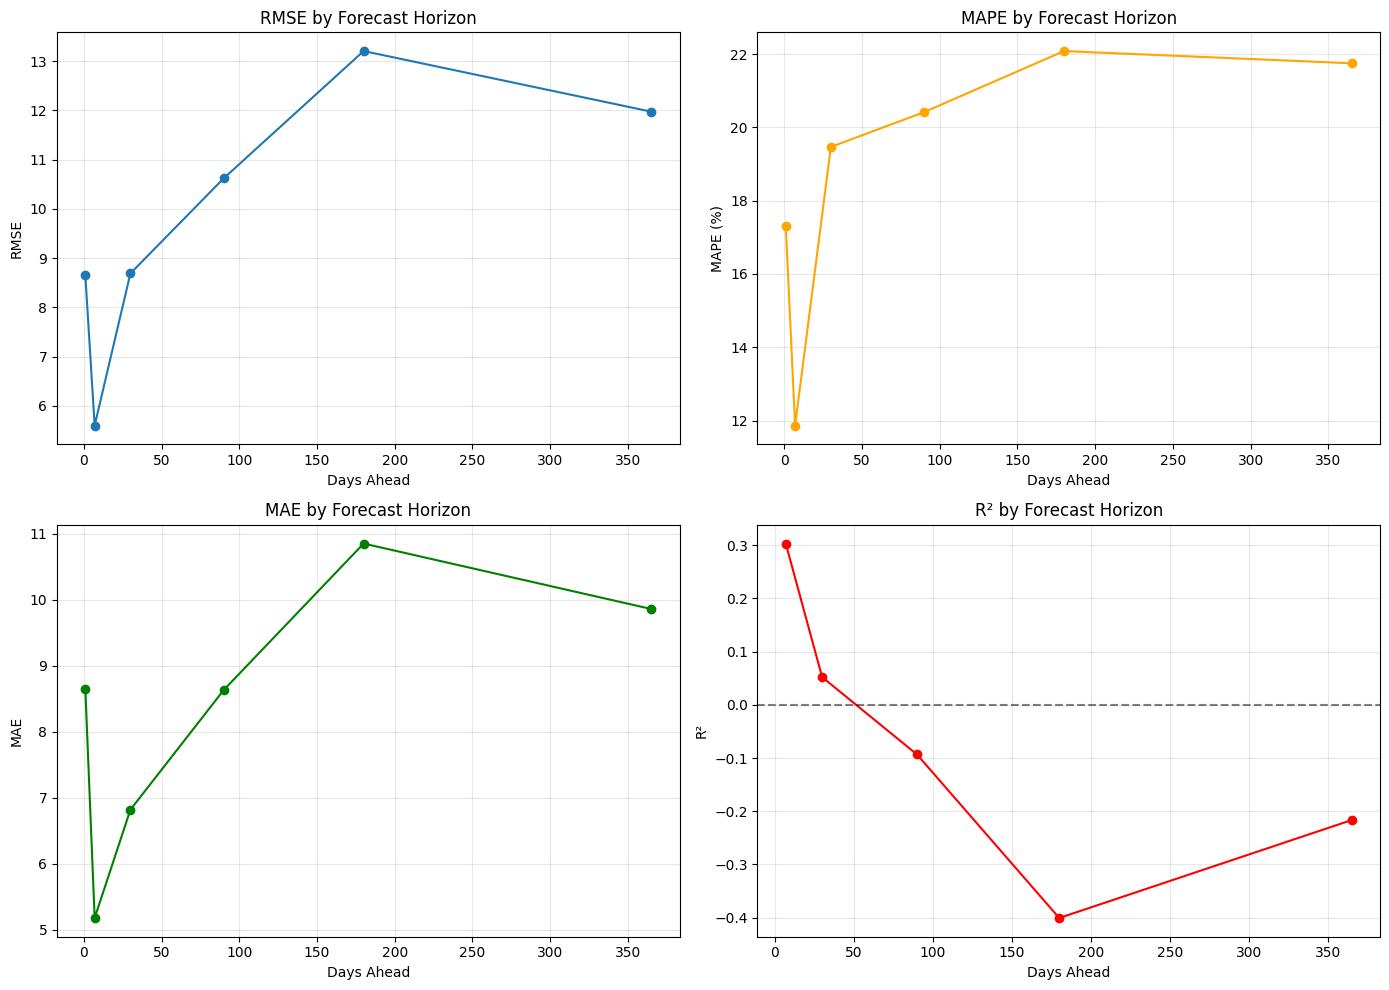


✓ Multi-horizon results saved


In [ ]:
# Evaluate ARIMA model at different forecast horizons
if len(test_data) > 0 and 'ARIMA' in forecasts:
    print("Multi-Horizon ARIMA Evaluation:")
    print("=" * 60)
    
    # Load ARIMA model if available
    arima_model = load_file('arima_model.pkl', MODELS_PATH, DRIVE_MODELS_PATH)
    arima_horizon_results = {}
    
    if arima_model is not None:
        try:
            
            # Evaluate at different horizons
            horizons = [1, 7, 30, 90, 180, 365]
            for horizon in horizons:
                if horizon <= len(test_data):
                    # Generate forecast for this horizon
                    forecast_h = arima_model.predict(n_periods=horizon)
                    actual_h = test_data.iloc[:horizon].values
                    
                    # Calculate metrics
                    metrics_h = calculate_all_metrics(actual_h, forecast_h)
                    arima_horizon_results[f'{horizon}-day'] = metrics_h
                    print(f"\n{horizon}-day ahead:")
                    print(f"  RMSE: {metrics_h['RMSE']:.3f}, MAE: {metrics_h['MAE']:.3f}, "
                          f"MAPE: {metrics_h['MAPE']:.2f}%, R²: {metrics_h['R2']:.3f}")
            
            # Create visualization
            if len(arima_horizon_results) > 0:
                horizon_df = pd.DataFrame(arima_horizon_results).T
                horizon_df.index = [int(h.replace('-day', '')) for h in horizon_df.index]
                horizon_df = horizon_df.sort_index()
                
                fig, axes = plt.subplots(2, 2, figsize=(14, 10))
                
                axes[0, 0].plot(horizon_df.index, horizon_df['RMSE'], marker='o')
                axes[0, 0].set_title('RMSE by Forecast Horizon')
                axes[0, 0].set_xlabel('Days Ahead')
                axes[0, 0].set_ylabel('RMSE')
                axes[0, 0].grid(True, alpha=0.3)
                
                axes[0, 1].plot(horizon_df.index, horizon_df['MAPE'], marker='o', color='orange')
                axes[0, 1].set_title('MAPE by Forecast Horizon')
                axes[0, 1].set_xlabel('Days Ahead')
                axes[0, 1].set_ylabel('MAPE (%)')
                axes[0, 1].grid(True, alpha=0.3)
                
                axes[1, 0].plot(horizon_df.index, horizon_df['MAE'], marker='o', color='green')
                axes[1, 0].set_title('MAE by Forecast Horizon')
                axes[1, 0].set_xlabel('Days Ahead')
                axes[1, 0].set_ylabel('MAE')
                axes[1, 0].grid(True, alpha=0.3)
                
                axes[1, 1].plot(horizon_df.index, horizon_df['R2'], marker='o', color='red')
                axes[1, 1].set_title('R² by Forecast Horizon')
                axes[1, 1].set_xlabel('Days Ahead')
                axes[1, 1].set_ylabel('R²')
                axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
                axes[1, 1].grid(True, alpha=0.3)
                
                plt.tight_layout()
                save_plot(plt.gcf(), 'arima_multi_horizon.png', RESULTS_PATH, DRIVE_RESULTS_PATH, 
                         dpi=300, bbox_inches='tight')
                plt.show()
                
                # Save results
                save_file(horizon_df, 'arima_multi_horizon.csv', RESULTS_PATH, DRIVE_RESULTS_PATH)
                print(f"\n✓ Multi-horizon results saved")
        except Exception as e:
            print(f"⚠️  Could not perform multi-horizon evaluation: {e}")
    else:
        print("ARIMA model file not found")
else:
    print("ARIMA forecasts not available for multi-horizon evaluation")


## Create Model Comparison Table


Model Comparison (sorted by RMSE):
                     RMSE     MAE    MAPE     R2
Seasonal_Naive_7   10.250   8.262  17.874  0.123
LSTM               10.916   8.830  22.286  0.006
VAR                10.931   8.901  21.671  0.003
ARIMAX             12.156   9.979  21.721 -0.233
ARIMA              12.250  10.048  21.723 -0.252
Moving_Average_30  12.676  10.387  22.079 -0.341
Enhanced_LSTM      19.542  14.588  35.609 -2.187
Naive              21.403  18.722  37.199 -2.822
SARIMAX            25.060  21.315  43.692 -4.240

✓ Comparison table saved to: /content/hospital_admissions_forecasting/results/visualizations/model_evaluation/model_comparison.csv


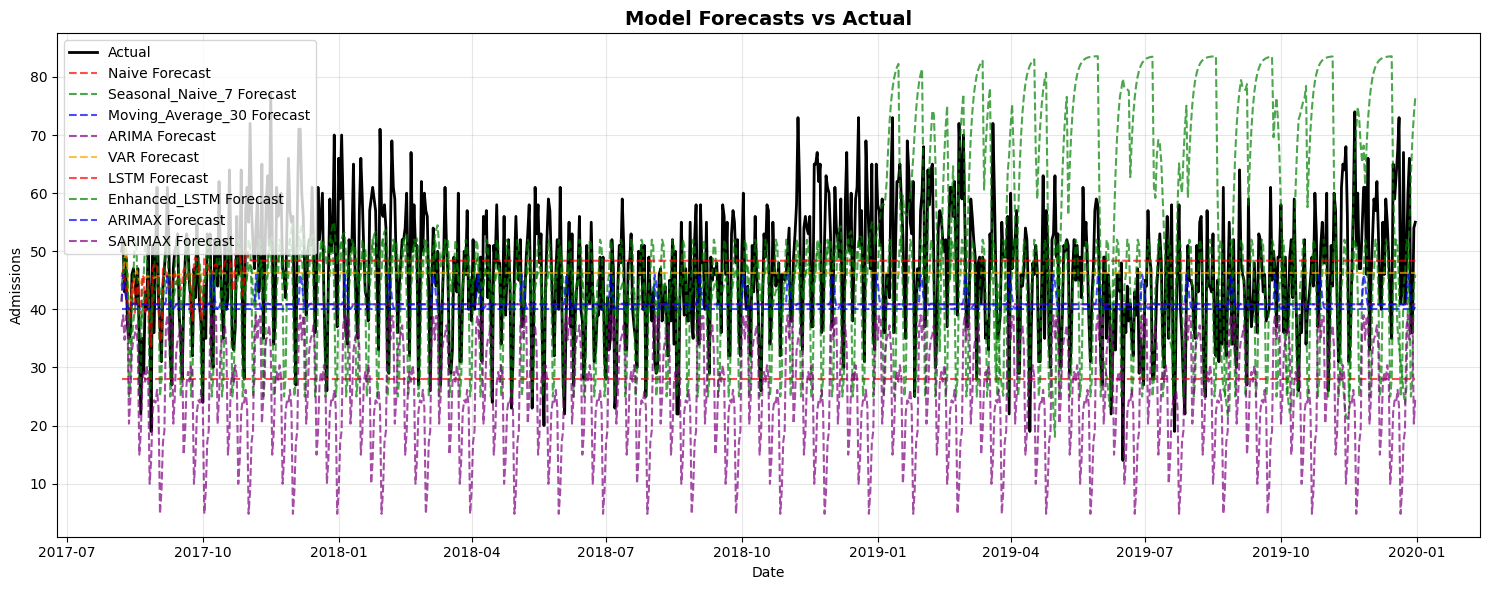

✓ Forecast comparison plot saved


In [ ]:
if len(model_results) > 0:
    comparison_df = pd.DataFrame(model_results).T
    comparison_df = comparison_df.sort_values('RMSE')  # Sort by RMSE (lower is better)
    print("Model Comparison (sorted by RMSE):")
    print("=" * 60)
    print(comparison_df.round(3))
    save_file(comparison_df, 'model_comparison.csv', RESULTS_PATH, DRIVE_RESULTS_PATH)
    print(f"\n✓ Comparison table saved")
    
    # Visualize forecasts vs actual
    if len(forecasts) > 0:
        plt.figure(figsize=(15, 6))
        plt.plot(test_data.index, test_data.values, label='Actual', color='black', linewidth=2)
        colors = ['red', 'green', 'blue', 'purple', 'orange']
        for i, (name, forecast) in enumerate(forecasts.items()):
            plt.plot(forecast.index, forecast.values, label=f'{name} Forecast', 
                    linestyle='--', alpha=0.7, color=colors[i % len(colors)])
        plt.title('Model Forecasts vs Actual', fontsize=14, fontweight='bold')
        plt.xlabel('Date')
        plt.ylabel('Admissions')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        save_plot(plt.gcf(), 'forecast_comparison.png', RESULTS_PATH, DRIVE_RESULTS_PATH, 
                 dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✓ Forecast comparison plot saved")
else:
    print("No model results available yet. Run notebook 04 first.")


## Summary

This notebook provides:
- Model evaluation framework
- Metrics calculation (RMSE, MAE, MAPE, R²)
- Model comparison table

**Next Steps:** Proceed to `06_forecasting.ipynb` to generate final forecasts with the best model.
